# Tugas Praktikum - Klasterisasi

**Nama:** Agus

**NIM:** 244107020049

## Langkah 0 - Persiapan Lingkungan

In [1]:
!pip install -q pandas numpy matplotlib scikit-learn

## Langkah 1 - Tugas KMeans: Memuat dan Memilih Fitur

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn import metrics
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
df_mall = pd.read_csv('data/Mall_Customers.csv')
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X_mall = df_mall[features]
display(df_mall.head())
print('Fitur yang dipilih:', features)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Fitur yang dipilih: ['Annual Income (k$)', 'Spending Score (1-100)']


## Langkah 2 - Visualisasi dan Penentuan k

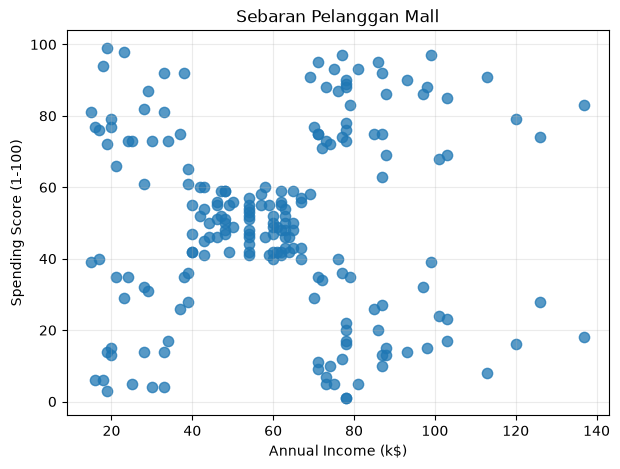

,k,SSE,Silhouette
0,2,181363.60,0.297
1,3,106348.37,0.468
2,4,73679.79,0.493
3,5,44448.46,0.554
4,6,37233.81,0.540
5,7,30241.34,0.529
6,8,25036.42,0.455
7,9,21916.79,0.456
8,10,20072.07,0.441


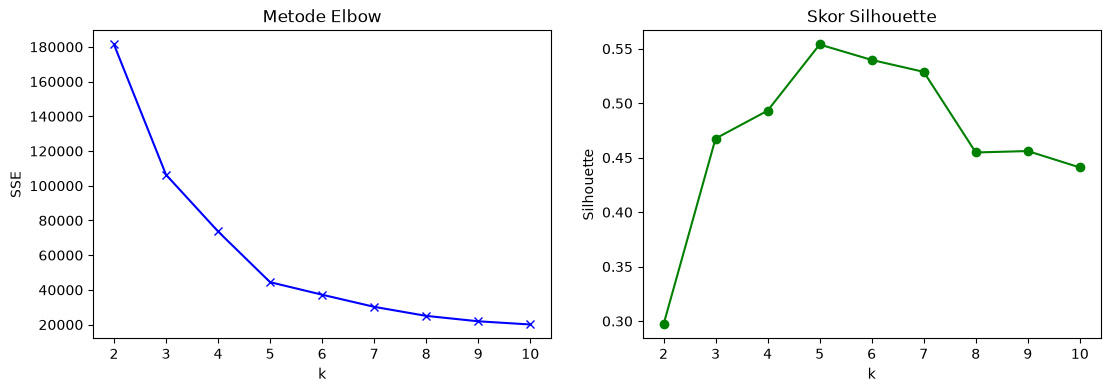

In [3]:
plt.figure(figsize=(7, 5)); plt.scatter(X_mall.iloc[:, 0], X_mall.iloc[:, 1], s=55, alpha=0.75)
plt.xlabel(features[0]); plt.ylabel(features[1]); plt.title('Sebaran Pelanggan Mall'); plt.grid(alpha=0.25); plt.show()
evaluasi_k = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = model.fit_predict(X_mall)
    evaluasi_k.append({'k': k, 'SSE': model.inertia_, 'Silhouette': metrics.silhouette_score(X_mall, labels_k)})
evaluasi_k = pd.DataFrame(evaluasi_k)
display(evaluasi_k.style.format({'SSE': '{:.2f}', 'Silhouette': '{:.3f}'}))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(evaluasi_k['k'], evaluasi_k['SSE'], 'bx-'); axes[0].set(title='Metode Elbow', xlabel='k', ylabel='SSE', xticks=evaluasi_k['k'])
axes[1].plot(evaluasi_k['k'], evaluasi_k['Silhouette'], 'go-'); axes[1].set(title='Skor Silhouette', xlabel='k', ylabel='Silhouette', xticks=evaluasi_k['k'])
plt.show()

## Langkah 3 - Model KMeans Terpilih

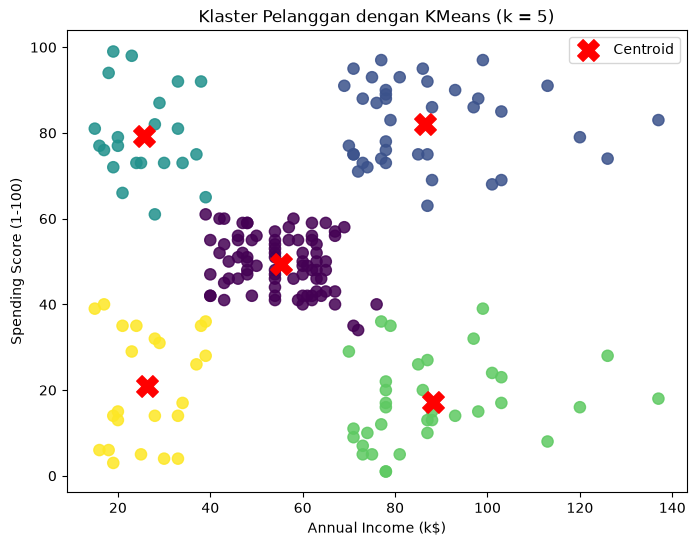

SSE untuk k=5: 44448.46
Silhouette untuk k=5: 0.554


In [4]:
k_terpilih = 5
kmeans_mall = KMeans(n_clusters=k_terpilih, random_state=42, n_init=10)
labels_mall = kmeans_mall.fit_predict(X_mall)
plt.figure(figsize=(8, 6))
plt.scatter(X_mall.iloc[:, 0], X_mall.iloc[:, 1], c=labels_mall, s=65, cmap='viridis', alpha=0.85)
centers_mall = kmeans_mall.cluster_centers_
plt.scatter(centers_mall[:, 0], centers_mall[:, 1], c='red', marker='X', s=240, label='Centroid')
plt.xlabel(features[0]); plt.ylabel(features[1]); plt.title(f'Klaster Pelanggan dengan KMeans (k = {k_terpilih})'); plt.legend(); plt.show()
print(f'SSE untuk k={k_terpilih}: {kmeans_mall.inertia_:.2f}')
print(f'Silhouette untuk k={k_terpilih}: {metrics.silhouette_score(X_mall, labels_mall):.3f}')

## Langkah 4 - Tugas DBSCAN: Dataset make_moons dan Normalisasi

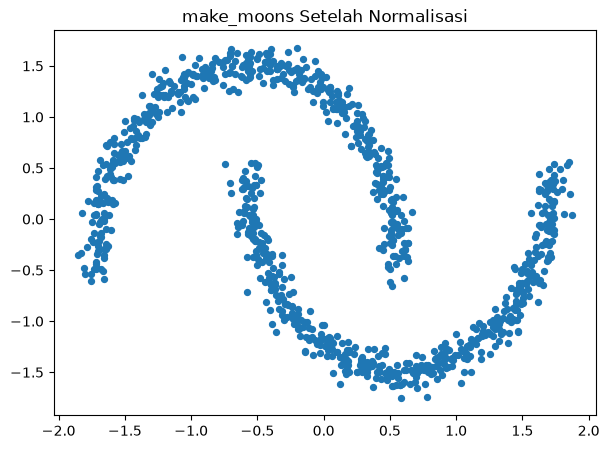

In [5]:
X_moons, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)
plt.figure(figsize=(7, 5)); plt.scatter(X_moons[:, 0], X_moons[:, 1], s=18)
plt.title('make_moons Setelah Normalisasi'); plt.show()

## Langkah 5 - Model dan Evaluasi DBSCAN

In [6]:
def ringkasan(X, labels, truth):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return {'Klaster': n_clusters, 'Noise': int(np.sum(labels == -1)),
            'Homogeneity': metrics.homogeneity_score(truth, labels),
            'Completeness': metrics.completeness_score(truth, labels),
            'V-measure': metrics.v_measure_score(truth, labels),
            'ARI': metrics.adjusted_rand_score(truth, labels),
            'AMI': metrics.adjusted_mutual_info_score(truth, labels),
            'Silhouette': metrics.silhouette_score(X, labels) if n_clusters >= 2 else np.nan}

db = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
labels_dbscan = db.labels_
display(pd.Series(ringkasan(X_moons, labels_dbscan, labels_true)).to_frame('Nilai').style.format('{:.3f}'))

,Nilai
Klaster,2.000
Noise,0.000
Homogeneity,1.000
Completeness,1.000
V-measure,1.000
ARI,1.000
AMI,1.000
Silhouette,0.391


## Langkah 6 - Visualisasi DBSCAN

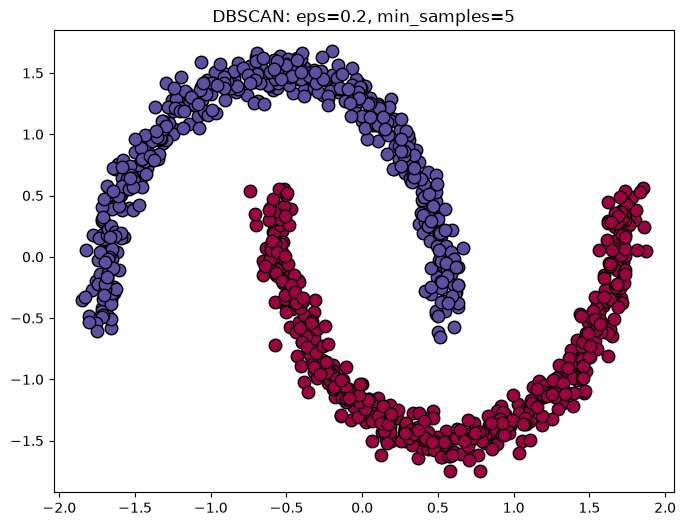

In [7]:
def plot_dbscan(X, model, labels, title):
    core_mask = np.zeros_like(labels, dtype=bool)
    core_mask[model.core_sample_indices_] = True
    colors = plt.cm.Spectral(np.linspace(0, 1, len(set(labels))))
    plt.figure(figsize=(8, 6))
    for label, color in zip(set(labels), colors):
        color = [0, 0, 0, 1] if label == -1 else color
        mask = labels == label
        core, non_core = X[mask & core_mask], X[mask & ~core_mask]
        plt.plot(core[:, 0], core[:, 1], 'o', markerfacecolor=tuple(color), markeredgecolor='k', markersize=9)
        plt.plot(non_core[:, 0], non_core[:, 1], 'o', markerfacecolor=tuple(color), markeredgecolor='k', markersize=4)
    plt.title(title); plt.show()

plot_dbscan(X_moons, db, labels_dbscan, 'DBSCAN: eps=0.2, min_samples=5')

## Langkah 7 - Eksperimen Parameter DBSCAN

In [8]:
hasil_eksperimen = []
for eps in [0.05, 0.1, 0.3, 0.5]:
    for min_samples in [3, 10, 20]:
        model = DBSCAN(eps=eps, min_samples=min_samples).fit(X_moons)
        hasil_eksperimen.append({'eps': eps, 'min_samples': min_samples, **ringkasan(X_moons, model.labels_, labels_true)})
hasil_eksperimen = pd.DataFrame(hasil_eksperimen)
display(hasil_eksperimen.style.format({'Homogeneity': '{:.3f}', 'Completeness': '{:.3f}', 'V-measure': '{:.3f}', 'ARI': '{:.3f}', 'AMI': '{:.3f}', 'Silhouette': '{:.3f}'}))

,eps,min_samples,Klaster,Noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.050000,3,69,186,0.816,0.153,0.257,0.030,0.244,0.113
1,0.050000,10,3,970,0.031,0.127,0.049,0.002,0.046,-0.294
2,0.050000,20,0,1000,0.000,1.000,0.000,0.000,0.000,nan
3,0.100000,3,2,14,0.986,0.903,0.943,0.972,0.943,0.252
4,0.100000,10,7,57,0.943,0.410,0.571,0.523,0.570,0.162
5,0.100000,20,6,850,0.154,0.155,0.155,0.017,0.151,-0.360
6,0.300000,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391
7,0.300000,10,2,0,1.000,1.000,1.000,1.000,1.000,0.391
8,0.300000,20,2,0,1.000,1.000,1.000,1.000,1.000,0.391
9,0.500000,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391


## Kesimpulan

Untuk data pelanggan, pendapatan tahunan dan skor belanja dipakai sebagai dua fitur klasterisasi. Pada data dua bulan sabit, perubahan eps dan min_samples memengaruhi jumlah noise serta kualitas klaster yang dihasilkan DBSCAN.